In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('placement.csv')

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
df.shape

(100, 4)

In [10]:
df = df.iloc[:,1:]

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [12]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [13]:
import matplotlib.pyplot as plt


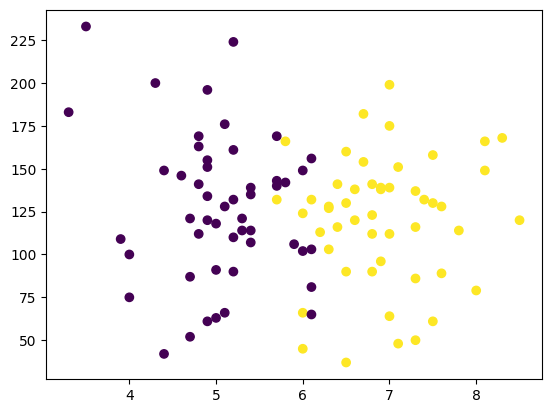

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [15]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [16]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
y.shape

(100,)

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [19]:
X_train

,cgpa,iq
79,6.5,90.0
36,5.7,140.0
25,5.0,91.0
82,6.5,37.0
87,5.7,132.0
...,...,...
44,7.5,61.0
16,5.2,224.0
9,5.1,66.0
32,7.0,139.0


In [20]:
y_train

79    1
36    0
25    0
82    1
87    1
     ..
44    1
16    0
9     0
32    1
54    1
Name: placement, Length: 90, dtype: int64

In [21]:
X_test

,cgpa,iq
51,4.8,141.0
67,5.0,118.0
14,6.1,103.0
78,6.1,81.0
39,4.6,146.0
22,4.9,120.0
84,5.7,169.0
94,4.7,52.0
37,8.1,149.0
8,6.1,156.0


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_train = scaler.fit_transform(X_train)

In [25]:
X_train

array([[ 0.40831774, -0.83398574],
       [-0.29165553,  0.40747501],
       [-0.90413213, -0.80915653],
       [ 0.40831774, -2.14993414],
       [-0.29165553,  0.20884129],
       [-0.02916555, -1.95130042],
       [ 0.05833111,  0.20884129],
       [-2.21658201,  2.716592  ],
       [-0.72913882, -0.33740144],
       [ 1.108291  ,  0.33298736],
       [ 0.40831774,  0.90405931],
       [-0.99162879, -1.55403298],
       [-0.02916555,  0.01020757],
       [ 0.67080771, -0.01462165],
       [ 0.23332442,  0.08469521],
       [ 0.67080771,  0.43230422],
       [ 0.75830437, -0.68501045],
       [-0.64164216, -0.23808458],
       [-0.02916555,  0.63093794],
       [-1.16662211, -0.06428008],
       [-0.99162879,  1.79791105],
       [ 1.108291  , -1.82715434],
       [ 0.40831774,  0.15918286],
       [-0.72913882,  0.20884129],
       [ 0.75830437,  0.35781658],
       [ 1.28328432,  0.15918286],
       [-1.16662211, -0.90847339],
       [-0.99162879,  0.25849972],
       [-0.72913882,

In [26]:
X_test = scaler.transform(X_test)

In [27]:
X_test

array([[-1.07912545,  0.43230422],
       [-0.90413213, -0.13876772],
       [ 0.05833111, -0.51120595],
       [ 0.05833111, -1.05744868],
       [-1.25411877,  0.5564503 ],
       [-0.99162879, -0.08910929],
       [-0.29165553,  1.12752224],
       [-1.16662211, -1.77749591],
       [ 1.80826427,  0.63093794],
       [ 0.05833111,  0.80474245]])

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf = LogisticRegression()

In [31]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [33]:
y_pred = clf.predict(X_test)

In [35]:
y_test

51    0
67    0
14    0
78    0
39    0
22    0
84    0
94    0
37    1
8     0
Name: placement, dtype: int64

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
print(accuracy_score(y_test,y_pred))

0.7


In [39]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

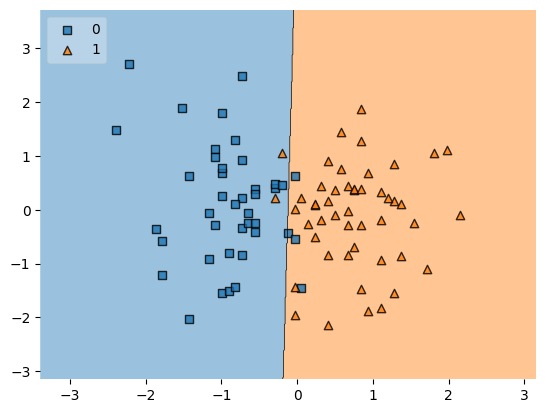

In [40]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [42]:
import pickle

In [43]:
pickle.dump(clf,open('model.pkl','wb'))

In [50]:
class LogisticRegression:
    def __init__(self,learning_rate,epochs):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights=None
        self.bias=None

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.weights=np.zeros(n_features)
        self.bias=0

        for i in range(self.epochs):
            linear_model=np.dot(X,self.weights)+self.bias
            y_pred=self.sigmoid(linear_model)

            dw=(1/n_samples)*np.dot(X.T,(y_pred-y))
            db=(1/n_samples)*np.sum(y_pred-y)

            self.weights-=self.learning_rate*dw
            self.bias-=self.learning_rate*db


    def predict(self,X):
        linear_model=np.dot(X,self.weights)+self.bias
        y_pred=self.sigmoid(linear_model)
        return[1 if i>0.5 else 0 for i in y_pred]

In [51]:
model1=LogisticRegression(learning_rate=0.1,epochs=1000)
model1.fit(X_train,y_train)

In [52]:
y_pred=model1.predict(X_test)

In [53]:
print(accuracy_score(y_pred,y_test))

0.7
